<a href="https://colab.research.google.com/github/Hamerson-jhoel/TOPICOS-VISION-ARTIFICIAL/blob/main/Reconstruccion_Estereo_v2interactivoo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reconstruccion 3D estereo — calibracion (Zhang), disparidad (SGBM + regularizacion) y nube de puntos 3D


---

## 1. Marco teorico

### 1.1 Calibracion (algoritmo de Zhang, 4 pasos) — repaso
1. Capturar N fotos de un patron plano (tablero de ajedrez) desde distintos angulos.
2. Detectar las esquinas del patron en cada imagen (`findChessboardCorners` + `cornerSubPix`).
3. Calcular una homografia `H` entre el plano del patron y el plano imagen para cada vista (DLT + SVD; ver seccion 5).
4. A partir de las `H` de todas las vistas, resolver los parametros intrinsecos `K` (via la matriz `B=K^-T K^-1`) y luego los extrinsecos `(R,t)` de cada vista, refinando todo con Levenberg-Marquardt (minimizando el error de reproyeccion) e incluyendo la distorsion `D`.

En codigo: `cv2.calibrateCamera()` implementa estos 4 pasos.

### 1.2 Geometria epipolar y calibracion estereo
- `K1,D1` y `K2,D2`: intrinsecos de cada camara.
- `R,T`: rotacion y traslacion de la camara 2 respecto a la camara 1 (`cv2.stereoCalibrate`), de forma que un punto `P1` visto desde la camara 1 se expresa en la camara 2 como:

$$ P_2 = R\,P_1 + T $$

- Matriz esencial y matriz fundamental (definen las **lineas epipolares**):

$$ E = [T]_\times R, \qquad F = K_2^{-T}\,E\,K_1^{-1}, \qquad p_2^{T} F\, p_1 = 0 $$

- **Rectificacion estereo** (`cv2.stereoRectify`): reproyecta ambas imagenes a un par de camaras virtuales coplanares y con ejes fila alineados, de forma que las lineas epipolares queden **horizontales**. Esto reduce la busqueda de correspondencias a **una sola dimension** (a lo largo de la fila).

### 1.3 Correspondencia por bloques (block matching) y mapas de disparidad
Una vez rectificadas las imagenes, para cada pixel `(x,y)` de la imagen izquierda se busca el pixel correspondiente en la imagen derecha **sobre la misma fila** `y`, dentro de un rango de busqueda `[0, numDisparities]`. Se compara una **ventana (bloque) de vecinos** alrededor de `(x,y)` contra ventanas candidatas en la fila derecha, usando un costo como SAD (Suma de Diferencias Absolutas):

$$ C(x,y,d) = \sum_{(i,j)\in \text{ventana}} \big| I_L(x+i,y+j) - I_R(x+i-d,\,y+j) \big| $$

(SSD y NCC son alternativas al mismo costo, elevando al cuadrado o normalizando). La **disparidad** es el desplazamiento que minimiza ese costo:

$$ d(x,y) = \arg\min_{d \in [0,\,d_{max}]} \; C(x,y,d) $$

es decir, **cuanto tuvo que "moverse" el contenido de una imagen respecto a la otra** para que las ventanas se parezcan lo mas posible.

### 1.4 Termino de regularizacion (suavidad) — por que SGBM y no solo "el minimo costo por pixel"
Elegir el minimo de `C(x,y,d)` pixel por pixel (block matching puro) da mapas de disparidad muy ruidosos, sobre todo en zonas sin textura (paredes lisas, madera, icopor). Por eso se agrega una **energia global** con un termino de regularizacion que penaliza cambios bruscos de disparidad entre pixeles vecinos:

$$ E(D) \;=\; \underbrace{\sum_{(x,y)} C\big(x,y,d(x,y)\big)}_{\text{termino de datos}} \;+\; \underbrace{\sum_{(x,y)\sim(x',y')} P_1 \cdot [\,|d(x,y)-d(x',y')|=1\,]}_{\text{regularizacion: saltos pequenos}} \;+\; \underbrace{\sum_{(x,y)\sim(x',y')} P_2 \cdot [\,|d(x,y)-d(x',y')|>1\,]}_{\text{regularizacion: saltos grandes (ruido)}} $$

**Semi-Global Block Matching (SGBM)**, que es la version que usa OpenCV del algoritmo *Semi-Global Matching* (Hirschmuller), aproxima la minimizacion de esta energia agregando el costo a lo largo de multiples direcciones (izquierda-derecha, arriba-abajo, diagonales) en vez de resolver la optimizacion 2D completa (que es NP-dificil). Los parametros `P1` y `P2` de `cv2.StereoSGBM_create` son exactamente esos pesos de regularizacion.

Mas abajo (seccion 13) implementamos una version simplificada **a mano**, con programacion dinamica en 1D por cada fila (scanline), para que quede explicito como el termino de datos y el de regularizacion compiten en la formula de energia.

### 1.5 De disparidad a profundidad, y notas sobre hardware/compresion
Con imagenes rectificadas, la relacion entre disparidad y profundidad es:

$$ Z = \frac{f \cdot b}{d} $$

donde `f` es la distancia focal (en pixeles), `b=||T||` es el **baseline** (distancia entre camaras) y `d` es la disparidad: `Z` es **inversamente proporcional** a `d` (puntos cercanos → disparidad grande; puntos lejanos → disparidad pequena). OpenCV automatiza esto con `cv2.reprojectImageTo3D(disparidad, Q)`, usando la matriz `Q` que entrega `stereoRectify`:

$$ \begin{bmatrix} X \\ Y \\ Z \\ W \end{bmatrix} = Q \begin{bmatrix} x \\ y \\ d(x,y) \\ 1 \end{bmatrix}, \qquad (X_{3D},Y_{3D},Z_{3D}) = \left(\tfrac{X}{W},\tfrac{Y}{W},\tfrac{Z}{W}\right) $$

**Nota sobre hardware (ASIC) y compresion (breve, contexto de clase):** en camaras de profundidad comerciales (ej. Intel RealSense, ZED, etc.) el calculo de SGM/disparidad en tiempo real se implementa muchas veces en **hardware dedicado (ASIC/FPGA)**, porque agregar costos en 8-16 direcciones por cada pixel y cada disparidad es muy pesado para un CPU/GPU generico a alta resolucion y baja latencia. Para transmitir o guardar mapas de disparidad/profundidad se usan formatos con **compresion sin perdidas** (PNG de 16 bits) cuando se necesita precision exacta, o **codecs de video adaptados** (extensiones de rango de HEVC/AV1) cuando se transmite profundidad como si fuera video, aprovechando que los mapas de profundidad suelen ser suaves por regiones (comprimen bien con prediccion espacial/temporal, similar a como se comprime el color).

### 1.6 Correspondencia dispersa: cuanto y en que direccion se "movio" cada punto
Ademas del mapa de disparidad denso, es util mirar **puntos caracteristicos** (esquinas, bordes con textura) emparejados entre ambas imagenes **sin rectificar**, y calcular para cada par:

- **Distancia** (magnitud del desplazamiento en pixeles): `dist = sqrt(dx^2+dy^2)`
- **Angulo** de ese desplazamiento: `angulo = atan2(dy,dx)`

Esto da una intuicion directa de "cuanto se movio" cada punto de una imagen a la otra (seccion 8), antes de pasar al mapa de disparidad denso.


## 2. Configuracion del entorno

In [ ]:
!pip -q install opencv-contrib-python==4.10.0.84 --upgrade

import cv2, os, re, glob, json, shutil, zipfile, time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (necesario para proyeccion 3d de matplotlib)
import plotly.graph_objects as go   # graficos 3D interactivos (rotar con el mouse, solo Colab/Jupyter)

print("OpenCV version:", cv2.__version__)
np.set_printoptions(suppress=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 11.3 MB/s eta 0:00:00
OpenCV version: 4.10.0


## 3. Subir el ZIP con todas las fotos

Sube el `.zip` que contiene TODAS tus carpetas de fotos (tablero de calibracion + objetos: caja, casas, bola de icopor, etc.). No importa la estructura interna de carpetas ni los nombres exactos de las subcarpetas: el notebook busca recursivamente todos los `.jpg/.jpeg/.png` y los agrupa automaticamente (ver seccion 4).

**Convencion que se espera en el NOMBRE del archivo** (esto si es importante): cada imagen debe tener `left` o `right` en el nombre, con un sufijo numerico, por ejemplo: `left_00.jpg`, `right_00.jpg`, `casa_left_02.jpg`, `bola_icopor_right_03.jpg`, etc.

In [ ]:
from google.colab import files

BASE_DIR = "/content/proyecto_estereo"
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)
os.makedirs(BASE_DIR, exist_ok=True)

print("Selecciona tu archivo .zip con todas las fotos...")
uploaded = files.upload()

zip_files = [f for f in uploaded.keys() if f.lower().endswith(".zip")]
assert len(zip_files) >= 1, "No subiste ningun archivo .zip"

for zf in zip_files:
    with zipfile.ZipFile(zf, 'r') as z:
        z.extractall(BASE_DIR)
    print(f"Descomprimido: {zf} -> {BASE_DIR}")

# Muestra el arbol de carpetas resultante (solo 3 niveles) para verificar
for root, dirs, fs in os.walk(BASE_DIR):
    nivel = root.replace(BASE_DIR, '').count(os.sep)
    if nivel > 3:
        continue
    print('  ' * nivel + os.path.basename(root) + '/')


Selecciona tu archivo .zip con todas las fotos...


Saving CalibracionCamara_CorrecionObjetos.zip to CalibracionCamara_CorrecionObjetos.zip
Descomprimido: CalibracionCamara_CorrecionObjetos.zip -> /content/proyecto_estereo
proyecto_estereo/
  CalibracionCamara_CorrecionObjetos/
    fotos_caja/
      fotos_caja/
    fotos_casas/
      fotos_casas/
    fotos_calibracion/
      fotos_calibracion/
    fotos_bola_icopor/
      fotos_bola_icopor/


## 4. Organizacion automatica de las imagenes

Se buscan **todas** las imagenes dentro del zip (sin importar la subcarpeta) y se agrupan por el texto que antecede a `left`/`right` en el nombre del archivo. Por ejemplo `casa_left_02.jpg` y `casa_right_02.jpg` caen en el grupo `casa`; `left_00.jpg`/`right_00.jpg` (sin prefijo) caen en un grupo que llamamos `calibracion` por defecto (se confirma/corrige automaticamente en la seccion 6).

In [ ]:
RESIZE_WIDTH = 1600  # ancho de trabajo (px) para TODAS las imagenes: velocidad sin perder precision util

def load_resized(path, width=RESIZE_WIDTH):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    h, w = img.shape[:2]
    scale = width / w
    return cv2.resize(img, (width, int(round(h * scale))), interpolation=cv2.INTER_AREA)

pat = re.compile(r'^(?P<prefix>.*?)(?P<side>left|right)_?(?P<idx>\d+)\.(jpg|jpeg|png)$', re.IGNORECASE)

def organizar_imagenes(base_dir):
    archivos = glob.glob(os.path.join(base_dir, "**", "*.*"), recursive=True)
    archivos = [f for f in archivos if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    grupos = {}
    for f in archivos:
        m = pat.match(os.path.basename(f))
        if not m:
            continue
        prefix = m.group('prefix').strip('_').strip('-').strip().lower()
        side = m.group('side').lower()
        key = prefix if prefix else 'calibracion'
        grupos.setdefault(key, {'left': [], 'right': []})
        grupos[key][side].append(f)
    for k in grupos:
        grupos[k]['left'].sort()
        grupos[k]['right'].sort()
    return grupos

grupos = organizar_imagenes(BASE_DIR)
print("Grupos detectados:")
for k, v in grupos.items():
    print(f"  - {k}: {len(v['left'])} izquierda / {len(v['right'])} derecha")

assert len(grupos) > 0, "No se encontraron imagenes con el patron *_left_NN / *_right_NN dentro del zip."


Grupos detectados:
  - caja: 4 izquierda / 4 derecha
  - casa: 4 izquierda / 4 derecha
  - calibracion: 10 izquierda / 10 derecha
  - bola_icopor: 4 izquierda / 4 derecha


## 5. Deteccion automatica del grupo de calibracion y tamano del tablero

Se prueba, para cada grupo, si sus primeras imagenes contienen un tablero de ajedrez detectable en varias combinaciones comunes de esquinas internas. El grupo (y tamano) que se detecte de forma consistente en varias imagenes se toma como el patron de calibracion; el resto de grupos se tratan como **objetos a reconstruir**.

In [ ]:
CANDIDATE_SIZES = [(11,8),(9,6),(8,6),(7,6),(6,5),(8,5),(7,5),(6,4),
                    (9,7),(10,7),(6,9),(11,7),(12,8),(5,7),(4,6)]

detect_flags = cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE

def prueba_tablero(gray, size):
    found, _ = cv2.findChessboardCorners(gray, size, flags=detect_flags)
    return found

def detectar_grupo_calibracion(grupos, n_muestra=3):
    for nombre, d in grupos.items():
        muestra = d['left'][:n_muestra]
        if len(muestra) < min(2, len(d['left'])):
            continue
        grays = [cv2.cvtColor(load_resized(f), cv2.COLOR_BGR2GRAY) for f in muestra]
        for size in CANDIDATE_SIZES:
            if all(prueba_tablero(g, size) for g in grays):
                return nombre, size
    return None, None

t0 = time.time()
NOMBRE_GRUPO_CALIB, CHECKERBOARD = detectar_grupo_calibracion(grupos)
print(f"Tiempo de auto-deteccion: {time.time()-t0:.1f}s")

if NOMBRE_GRUPO_CALIB is None:
    raise RuntimeError(
        "No se pudo detectar automaticamente el tablero de calibracion. "
        "Define manualmente NOMBRE_GRUPO_CALIB (uno de los grupos de arriba) y CHECKERBOARD=(columnas,filas)."
    )

print(f"Grupo de calibracion: '{NOMBRE_GRUPO_CALIB}'  |  Tablero (esquinas internas): {CHECKERBOARD}")

grupos_objeto = {k: v for k, v in grupos.items() if k != NOMBRE_GRUPO_CALIB}
print("Grupos que se reconstruiran en 3D:", list(grupos_objeto.keys()))


Tiempo de auto-deteccion: 31.9s
Grupo de calibracion: 'calibracion'  |  Tablero (esquinas internas): (11, 8)
Grupos que se reconstruiran en 3D: ['caja', 'casa', 'bola_icopor']


In [ ]:
# Mide (con una regla) el tamano real de cada cuadro del tablero, en milimetros
SQUARE_SIZE_MM = 25.0  # <-- AJUSTA ESTE VALOR a tu tablero fisico


## 6. Deteccion de esquinas y calibracion individual de cada camara (Zhang completo)

Detectando esquinas en 10 imagenes IZQUIERDAS...


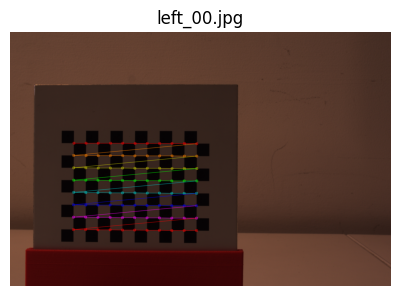

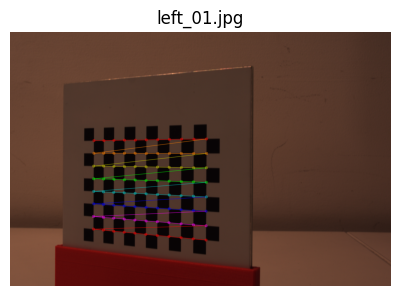

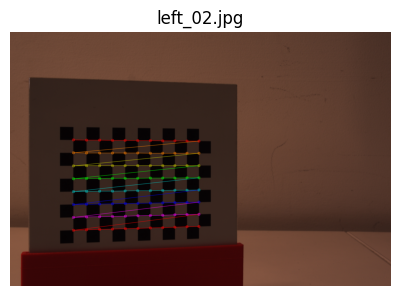


Detectando esquinas en 10 imagenes DERECHAS...


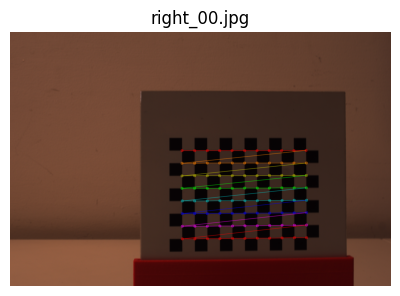

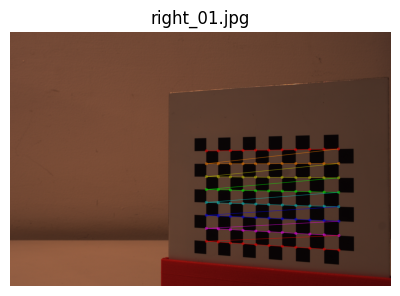

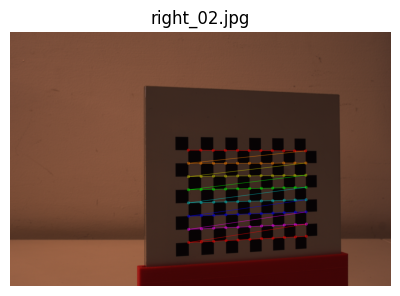


Validas: 10 izquierda, 10 derecha (de 10 c/u)


In [ ]:
objp = np.zeros((CHECKERBOARD[0]*CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
objp *= SQUARE_SIZE_MM

criteria_subpix = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1e-4)

def detectar_esquinas(files, mostrar=False, max_mostrar=3):
    objpoints, imgpoints, validos, shape_ = [], [], [], None
    mostrados = 0
    for f in files:
        img = load_resized(f)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        shape_ = gray.shape[::-1]
        found, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, flags=detect_flags)
        if found:
            corners_sub = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria_subpix)
            objpoints.append(objp.copy())
            imgpoints.append(corners_sub)
            validos.append(f)
            if mostrar and mostrados < max_mostrar:
                vis = img.copy()
                cv2.drawChessboardCorners(vis, CHECKERBOARD, corners_sub, found)
                plt.figure(figsize=(5, 3.3))
                plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.title(os.path.basename(f)); plt.axis("off")
                plt.show()
                mostrados += 1
        else:
            print(f"  (sin deteccion, se descarta): {os.path.basename(f)}")
    return objpoints, imgpoints, shape_, validos

calib_L_files = grupos[NOMBRE_GRUPO_CALIB]['left']
calib_R_files = grupos[NOMBRE_GRUPO_CALIB]['right']

print(f"Detectando esquinas en {len(calib_L_files)} imagenes IZQUIERDAS...")
objpoints_L, imgpoints_L, IMG_SHAPE, valid_L = detectar_esquinas(calib_L_files, mostrar=True)

print(f"\nDetectando esquinas en {len(calib_R_files)} imagenes DERECHAS...")
objpoints_R, imgpoints_R, _, valid_R = detectar_esquinas(calib_R_files, mostrar=True)

print(f"\nValidas: {len(valid_L)} izquierda, {len(valid_R)} derecha (de {len(calib_L_files)} c/u)")


## 6.1 Homografia `H` manual (DLT + SVD) — la pieza que pidio el profesor en detalle

Antes de llamar a `cv2.calibrateCamera` (que resuelve todo internamente), implementamos **desde cero** el calculo de `H` para una sola vista del tablero, siguiendo los 4 pasos formales:

**Paso 1 — Normalizar.** Se traslada cada conjunto de puntos a su centroide y se escala para que la distancia RMS al origen sea `sqrt(2)` (mejora el condicionamiento numerico del sistema).

**Paso 2 — Generar las ecuaciones.** Cada correspondencia plano→imagen `(x,y) -> (x',y')` cumple `p' \times H p = 0`, lo que da **2 ecuaciones lineales** por punto:

$$ \begin{bmatrix} -x & -y & -1 & 0 & 0 & 0 & xx' & yx' & x' \\ 0 & 0 & 0 & -x & -y & -1 & xy' & yy' & y' \end{bmatrix} \begin{bmatrix} h_1\\ \vdots \\ h_9 \end{bmatrix} = 0 $$

Apilando todas las correspondencias se arma una matriz `A` de tamano `2N x 9`.

**Paso 3 — Grados de libertad y puntos minimos.** `H` (3x3) tiene 9 entradas pero solo se define hasta escala → **8 grados de libertad**. Cada punto aporta 2 ecuaciones, asi que se necesitan **minimo 4 puntos no colineales** (4×2 = 8 ecuaciones).

**Paso 4 — Resolver por SVD.** Se calcula `A = U Σ Vᵀ` y la solucion `h` es la **ultima columna de `V`** (el vector singular del menor valor singular), que minimiza `||Ah||` sujeto a `||h||=1`. Se reordena `h` como matriz 3x3 y se desnormaliza.

In [ ]:
def normalizar_puntos(pts):
    pts = np.asarray(pts, dtype=np.float64)
    centroide = pts.mean(axis=0)
    dist = np.sqrt(((pts - centroide) ** 2).sum(axis=1))
    escala = np.sqrt(2) / (dist.mean() + 1e-12)
    T = np.array([[escala, 0, -escala*centroide[0]],
                  [0, escala, -escala*centroide[1]],
                  [0, 0, 1]])
    pts_h = np.hstack([pts, np.ones((pts.shape[0], 1))])
    pts_norm = (T @ pts_h.T).T
    return pts_norm[:, :2], T

def compute_homography_dlt(pts_src, pts_dst):
    """H (3x3, 8 DOF) tal que pts_dst_h ~ H @ pts_src_h, via DLT normalizado + SVD.
    Requiere minimo 4 correspondencias no colineales (4 puntos x 2 ecuaciones = 8 ecuaciones)."""
    assert len(pts_src) >= 4, "Se necesitan minimo 4 puntos para calcular H (8 DOF)."
    src_n, T_src = normalizar_puntos(pts_src)   # Paso 1
    dst_n, T_dst = normalizar_puntos(pts_dst)

    A = []                                       # Paso 2: sistema de ecuaciones (2N x 9)
    for (x, y), (xp, yp) in zip(src_n, dst_n):
        A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp])
        A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp])
    A = np.array(A)                              # Paso 3: min. 4 puntos ya garantizado por el assert

    _, _, Vt = np.linalg.svd(A)                  # Paso 4: SVD -> ultima columna de V
    H = (Vt[-1]).reshape(3, 3)
    H = np.linalg.inv(T_dst) @ H @ T_src         # desnormalizar
    return H / H[2, 2]

# --- Demostracion con la primera vista valida del tablero (izquierda) ---
img_pts_demo = imgpoints_L[0].reshape(-1, 2)     # esquinas detectadas en la imagen
plane_pts_demo = objpoints_L[0][:, :2]           # coordenadas (X,Y) del patron, Z=0

H_manual = compute_homography_dlt(plane_pts_demo, img_pts_demo)
H_opencv, _ = cv2.findHomography(plane_pts_demo, img_pts_demo, method=0)

print("H calculada manualmente (DLT + SVD):\n", np.round(H_manual, 4))
print("\nH de referencia (cv2.findHomography):\n", np.round(H_opencv / H_opencv[2, 2], 4))

plane_h = np.hstack([plane_pts_demo, np.ones((len(plane_pts_demo), 1))])
proj = (H_manual @ plane_h.T).T
proj = proj[:, :2] / proj[:, 2:3]
err = np.linalg.norm(proj - img_pts_demo, axis=1).mean()
print(f"\nError medio de reproyeccion con H manual: {err:.3f} px  (validacion de que la formula esta bien implementada)")


H calculada manualmente (DLT + SVD):
 [[  2.0385  -0.0081 267.3907]
 [ -0.0096   2.0676 469.6542]
 [ -0.      -0.       1.    ]]

H de referencia (cv2.findHomography):
 [[  2.0385  -0.0081 267.3895]
 [ -0.0095   2.0676 469.6544]
 [ -0.      -0.       1.    ]]

Error medio de reproyeccion con H manual: 0.117 px  (validacion de que la formula esta bien implementada)


## 6.2 Calibracion individual — tabla de error de reproyeccion por imagen

In [ ]:
import pandas as pd

def calibrar_camara(objpoints, imgpoints, shape_, nombre="camara"):
    ret, K, D, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, shape_, None, None)
    errores = []
    for i in range(len(objpoints)):
        proj, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], K, D)
        errores.append(cv2.norm(imgpoints[i], proj, cv2.NORM_L2) / len(proj))
    print(f"--- Calibracion {nombre} ---")
    print("RMS OpenCV:", round(ret, 4), " | Error medio reproyeccion:", round(np.mean(errores), 4), "px")
    print("K =\n", np.round(K, 2))
    print("D =", np.round(D.ravel(), 5), "\n")
    return K, D, rvecs, tvecs, errores

K1, D1, rvecs_L, tvecs_L, err_L = calibrar_camara(objpoints_L, imgpoints_L, IMG_SHAPE, "CAMARA IZQUIERDA")
K2, D2, rvecs_R, tvecs_R, err_R = calibrar_camara(objpoints_R, imgpoints_R, IMG_SHAPE, "CAMARA DERECHA")

n = min(len(err_L), len(err_R))
tabla_calib = pd.DataFrame({
    "imagen_izq": [os.path.basename(f) for f in valid_L[:n]],
    "error_izq_px": np.round(err_L[:n], 4),
    "imagen_der": [os.path.basename(f) for f in valid_R[:n]],
    "error_der_px": np.round(err_R[:n], 4),
})
tabla_calib


--- Calibracion CAMARA IZQUIERDA ---
RMS OpenCV: 0.0696  | Error medio reproyeccion: 0.0073 px
K =
 [[1985.77    0.    818.66]
 [   0.   1985.08  523.57]
 [   0.      0.      1.  ]]
D = [-0.09866  0.60224 -0.00232  0.00263 -1.71618] 

--- Calibracion CAMARA DERECHA ---
RMS OpenCV: 0.0653  | Error medio reproyeccion: 0.0069 px
K =
 [[1978.98    0.    812.85]
 [   0.   1978.86  526.59]
 [   0.      0.      1.  ]]
D = [-0.05448  0.05745 -0.00019  0.00276  0.20027] 



,imagen_izq,error_izq_px,imagen_der,error_der_px
0,left_00.jpg,0.0082,right_00.jpg,0.0073
1,left_01.jpg,0.0075,right_01.jpg,0.0073
2,left_02.jpg,0.0085,right_02.jpg,0.0066
3,left_03.jpg,0.0061,right_03.jpg,0.0062
4,left_04.jpg,0.0060,right_04.jpg,0.0060
5,left_05.jpg,0.0057,right_05.jpg,0.0057
6,left_06.jpg,0.0090,right_06.jpg,0.0064
7,left_07.jpg,0.0066,right_07.jpg,0.0100
8,left_08.jpg,0.0083,right_08.jpg,0.0066
9,left_09.jpg,0.0074,right_09.jpg,0.0067


## 7. Correccion de distorsion de lente (antes / despues)

Con `K` y `D` ya calculados, se puede eliminar la distorsion radial/tangencial de cualquier imagen (`cv2.undistort`). Esto es necesario antes de trabajar con geometria epipolar y disparidad.

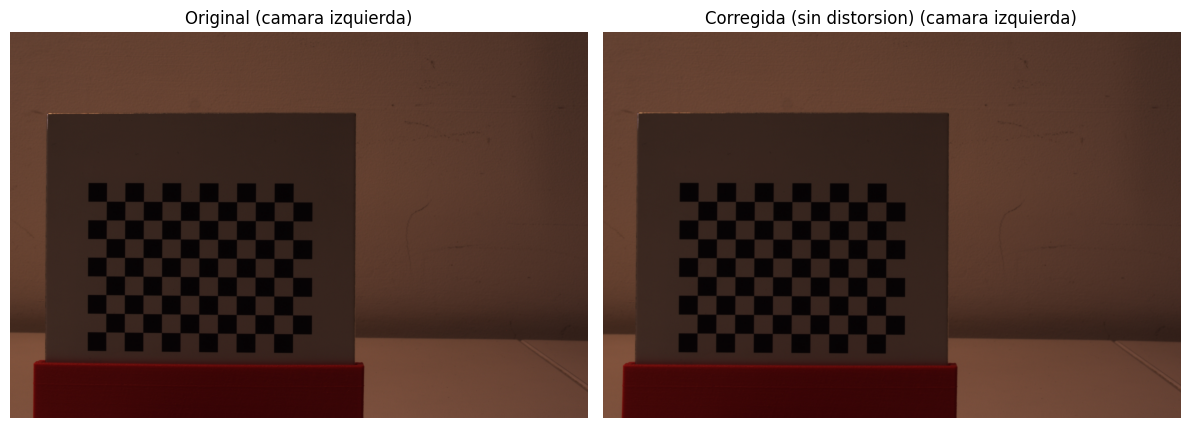

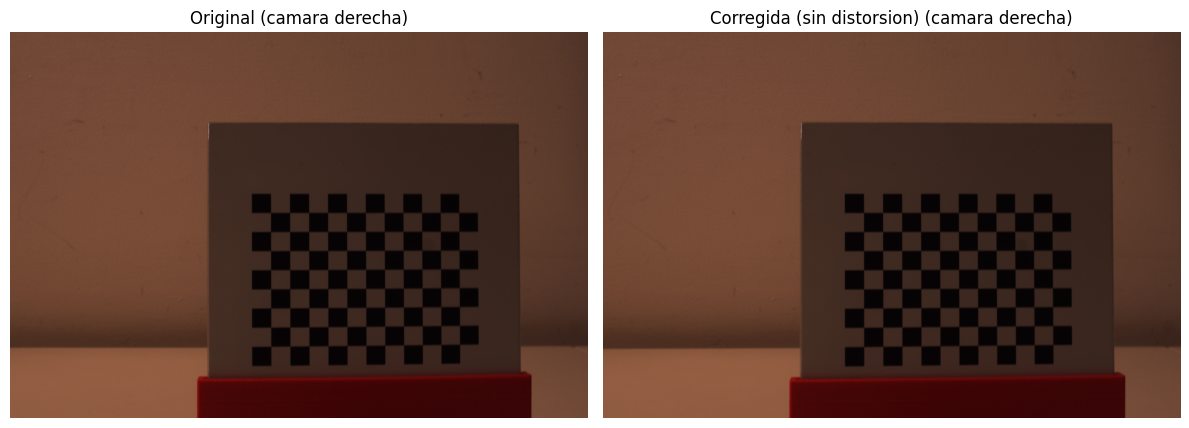

In [ ]:
def mostrar_correccion_distorsion(path_img, K, D, titulo=""):
    img = load_resized(path_img)
    und = cv2.undistort(img, K, D)
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axs[0].set_title(f"Original ({titulo})"); axs[0].axis("off")
    axs[1].imshow(cv2.cvtColor(und, cv2.COLOR_BGR2RGB)); axs[1].set_title(f"Corregida (sin distorsion) ({titulo})"); axs[1].axis("off")
    plt.tight_layout(); plt.show()
    return und

_ = mostrar_correccion_distorsion(valid_L[0], K1, D1, "camara izquierda")
_ = mostrar_correccion_distorsion(valid_R[0], K2, D2, "camara derecha")


## 8. Calibracion estereo — `R`, `T`, `E`, `F`

Se usan solo los pares donde **ambas** camaras detectaron el tablero simultaneamente.

In [ ]:
sufijos_L = [os.path.basename(f).split('left')[-1] for f in valid_L]
sufijos_R = [os.path.basename(f).split('right')[-1] for f in valid_R]
pares_validos = sorted(set(sufijos_L) & set(sufijos_R))
print(f"Pares validos para calibracion estereo: {len(pares_validos)}")

objpoints_stereo, imgpoints_L_stereo, imgpoints_R_stereo = [], [], []
for suf in pares_validos:
    iL, iR = sufijos_L.index(suf), sufijos_R.index(suf)
    objpoints_stereo.append(objpoints_L[iL])
    imgpoints_L_stereo.append(imgpoints_L[iL])
    imgpoints_R_stereo.append(imgpoints_R[iR])

assert len(objpoints_stereo) >= 1, "No hay pares simultaneos suficientes para calibracion estereo."

flags_stereo = cv2.CALIB_FIX_INTRINSIC
crit_stereo = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 150, 1e-5)

ret_s, K1, D1, K2, D2, R, T, E, F = cv2.stereoCalibrate(
    objpoints_stereo, imgpoints_L_stereo, imgpoints_R_stereo,
    K1, D1, K2, D2, IMG_SHAPE, criteria=crit_stereo, flags=flags_stereo
)

print("RMS calibracion estereo:", round(ret_s, 4), "px")
print("R =\n", np.round(R, 4))
print("T (mm) =", np.round(T.ravel(), 2), " | baseline =", round(float(np.linalg.norm(T)), 2), "mm")
if ret_s > 2.0:
    print("\nAVISO: el RMS estereo es alto (>2 px). Esto es normal si las fotos se tomaron moviendo una sola")
    print("camara a mano (sin un rig rigido). La reconstruccion sera aproximada; para mejor precision usa un")
    print("soporte fijo para ambas camaras y toma mas pares (12-20) del tablero en distintas posiciones.")


Pares validos para calibracion estereo: 10
RMS calibracion estereo: 4.7777 px
R =
 [[ 0.9979  0.008  -0.0648]
 [-0.0061  0.9995  0.0296]
 [ 0.065  -0.0291  0.9975]]
T (mm) = [284.95  -8.69   4.13]  | baseline = 285.11 mm

AVISO: el RMS estereo es alto (>2 px). Esto es normal si las fotos se tomaron moviendo una sola
camara a mano (sin un rig rigido). La reconstruccion sera aproximada; para mejor precision usa un
soporte fijo para ambas camaras y toma mas pares (12-20) del tablero en distintas posiciones.


## 9. Rectificacion estereo + deteccion automatica de convencion izquierda/derecha

Si tus fotos "left"/"right" no vinieron de un rig con orientacion estandar, la disparidad puede salir con signo invertido. Esta celda hace una prueba rapida con puntos caracteristicos (SIFT) sobre el propio tablero para decidir automaticamente si hay que "intercambiar" las camaras antes de calcular disparidad; si es asi, se hace de forma transparente (invirtiendo `R,T`) y el resto del notebook ya queda coherente.

Mediana de disparidad de prueba: -790.6 px (con 1 correspondencias)
>> Convencion invertida detectada: se intercambian los roles de camara 1 y camara 2.
   Mediana de disparidad tras intercambiar: 788.3 px (con 5 correspondencias)

Disparidad maxima estimada para configurar la busqueda: ~1027 px (a 1600px de ancho)


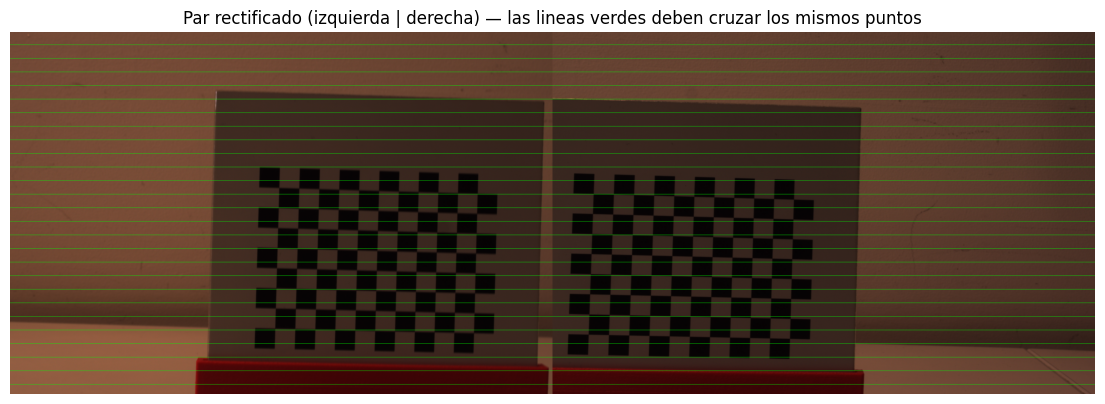

In [ ]:
def calcular_mapas_rectificacion(K1, D1, K2, D2, R, T, shape_):
    R1, R2, P1, P2, Q, roi1, roi2 = cv2.stereoRectify(K1, D1, K2, D2, shape_, R, T, alpha=0)
    m1x, m1y = cv2.initUndistortRectifyMap(K1, D1, R1, P1, shape_, cv2.CV_32FC1)
    m2x, m2y = cv2.initUndistortRectifyMap(K2, D2, R2, P2, shape_, cv2.CV_32FC1)
    return (m1x, m1y), (m2x, m2y), Q

def rectificar_par(imgL, imgR, mapsL, mapsR):
    rL = cv2.remap(imgL, mapsL[0], mapsL[1], cv2.INTER_LINEAR)
    rR = cv2.remap(imgR, mapsR[0], mapsR[1], cv2.INTER_LINEAR)
    return rL, rR

def mediana_disparidad_sift(rL, rR, max_dy=15):
    grayL = cv2.cvtColor(rL, cv2.COLOR_BGR2GRAY)
    grayR = cv2.cvtColor(rR, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    kpL, desL = sift.detectAndCompute(grayL, None)
    kpR, desR = sift.detectAndCompute(grayR, None)
    if desL is None or desR is None or len(kpL) < 4 or len(kpR) < 4:
        return 0.0, 0
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(desL, desR, k=2)
    dx = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            xl, yl = kpL[m.queryIdx].pt
            xr, yr = kpR[m.trainIdx].pt
            if abs(yl - yr) < max_dy:
                dx.append(xl - xr)
    if not dx:
        return 0.0, 0
    return float(np.median(dx)), len(dx)

# Rectificacion inicial (tal como quedo calibrado)
mapsL, mapsR, Q = calcular_mapas_rectificacion(K1, D1, K2, D2, R, T, IMG_SHAPE)
img_test_L, img_test_R = load_resized(valid_L[0]), load_resized(valid_R[0])
rL, rR = rectificar_par(img_test_L, img_test_R, mapsL, mapsR)
med, n = mediana_disparidad_sift(rL, rR)
print(f"Mediana de disparidad de prueba: {med:.1f} px (con {n} correspondencias)")

INTERCAMBIAR = med < 0
if INTERCAMBIAR:
    print(">> Convencion invertida detectada: se intercambian los roles de camara 1 y camara 2.")
    K1, D1, K2, D2 = K2, D2, K1, D1
    R, T = R.T, -R.T @ T
    mapsL, mapsR, Q = calcular_mapas_rectificacion(K1, D1, K2, D2, R, T, IMG_SHAPE)
    # OJO: a partir de aqui, "L" logico = archivos 'right' originales y viceversa
    calib_L_files, calib_R_files = calib_R_files, calib_L_files
    for g in grupos_objeto.values():
        g['left'], g['right'] = g['right'], g['left']
    rL, rR = rectificar_par(load_resized(calib_L_files[0]), load_resized(calib_R_files[0]), mapsL, mapsR)
    med2, n2 = mediana_disparidad_sift(rL, rR)
    print(f"   Mediana de disparidad tras intercambiar: {med2:.1f} px (con {n2} correspondencias)")

DISPARIDAD_MAXIMA_ESTIMADA = max(64, int(abs(med) * 1.3))
print(f"\nDisparidad maxima estimada para configurar la busqueda: ~{DISPARIDAD_MAXIMA_ESTIMADA} px (a {RESIZE_WIDTH}px de ancho)")

# Visualizacion de la rectificacion final (lineas horizontales deben alinear los mismos puntos)
combo = np.hstack([rL, rR])
for y in range(0, combo.shape[0], 40):
    cv2.line(combo, (0, y), (combo.shape[1], y), (0, 255, 0), 1)
plt.figure(figsize=(14, 6))
plt.imshow(cv2.cvtColor(combo, cv2.COLOR_BGR2RGB))
plt.title("Par rectificado (izquierda | derecha) — las lineas verdes deben cruzar los mismos puntos")
plt.axis("off"); plt.show()


## 9.1 Resumen impreso de todos los parametros de calibracion

`K1,D1,K2,D2` salen de la calibracion individual (seccion 6). `R,T` salen de la calibracion estereo (seccion 8). `E,F,Q` se calculan a partir de esos (seccion 9). Aqui se imprimen todos juntos, en un solo lugar, para el informe.

In [ ]:
print("="*70)
print("PARAMETROS INTRINSECOS")
print("="*70)
print("K1 (camara izquierda) =\n", K1)
print("D1 (distorsion izquierda) =", D1.ravel())
print()
print("K2 (camara derecha) =\n", K2)
print("D2 (distorsion derecha) =", D2.ravel())

print()
print("="*70)
print("PARAMETROS EXTRINSECOS (camara 2 respecto a camara 1)")
print("="*70)
print("R (rotacion) =\n", R)
print("T (traslacion, mm) =", T.ravel())
print("Baseline ||T|| =", round(float(np.linalg.norm(T)), 2), "mm")

print()
print("="*70)
print("GEOMETRIA EPIPOLAR")
print("="*70)
print("E (matriz esencial) =\n", E)
print("F (matriz fundamental) =\n", F)

print()
print("="*70)
print("MATRIZ DE REPROYECCION Q (disparidad -> profundidad 3D)")
print("="*70)
print("Q =\n", Q)


PARAMETROS INTRINSECOS
K1 (camara izquierda) =
 [[1978.97745516    0.          812.84604726]
 [   0.         1978.85807215  526.58932317]
 [   0.            0.            1.        ]]
D1 (distorsion izquierda) = [-0.05448381  0.05744959 -0.00018569  0.00276384  0.20026848]

K2 (camara derecha) =
 [[1985.77285876    0.          818.66186801]
 [   0.         1985.08067741  523.56724669]
 [   0.            0.            1.        ]]
D2 (distorsion derecha) = [-0.09865806  0.60223536 -0.00232081  0.00262801 -1.71618262]

PARAMETROS EXTRINSECOS (camara 2 respecto a camara 1)
R (rotacion) =
 [[ 0.99786387 -0.00606836  0.06504512]
 [ 0.00797833  0.99954337 -0.02914443]
 [-0.06483856  0.02960113  0.99745663]]
T (traslacion, mm) = [-284.6596333     6.53698495   14.61440668]
Baseline ||T|| = 285.11 mm

GEOMETRIA EPIPOLAR
E (matriz esencial) =
 [[  -0.54044729   -3.87373269   -8.79413014]
 [ -14.41423119    8.33756036 -284.48998039]
 [   6.94628756  284.88623518    7.87104409]]
F (matriz fundamen

## 10. Geometria epipolar — verificacion visual con `F`

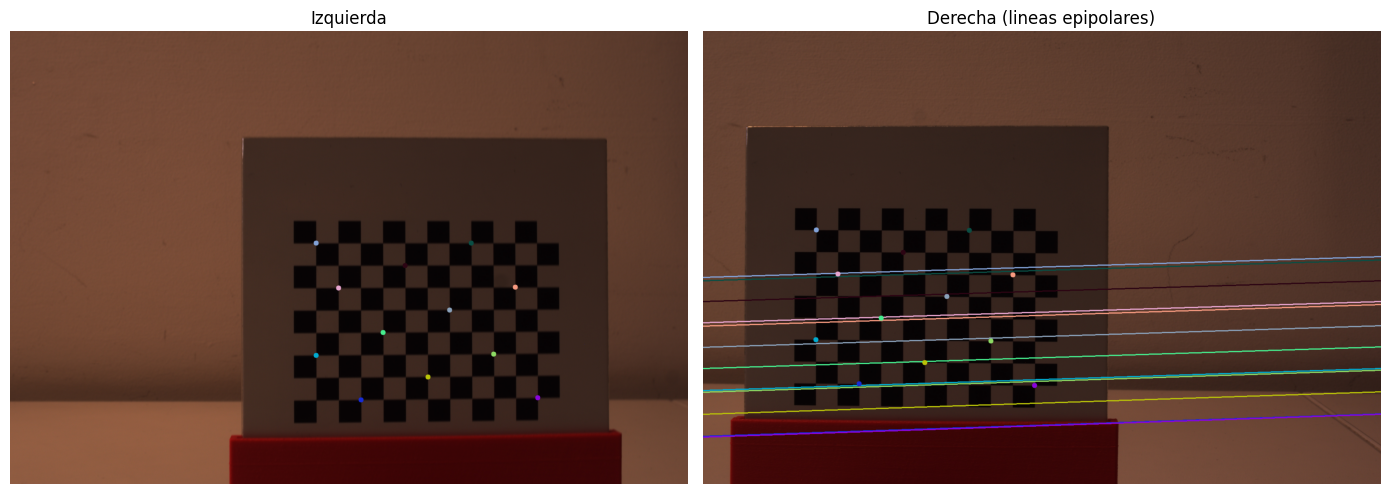

In [ ]:
def dibujar_lineas_epipolares(imgL, imgR, ptsL, ptsR, F, n_puntos=12):
    imgL_c, imgR_c = imgL.copy(), imgR.copy()
    idx = np.linspace(0, len(ptsL) - 1, min(n_puntos, len(ptsL))).astype(int)
    ptsL_sel = ptsL[idx].reshape(-1, 1, 2)
    ptsR_sel = ptsR[idx].reshape(-1, 1, 2)
    lineas_R = cv2.computeCorrespondEpilines(ptsL_sel, 1, F).reshape(-1, 3)
    h, w = imgL.shape[:2]
    rng = np.random.default_rng(0)
    for (a, b, c), ptL, ptR in zip(lineas_R, ptsL_sel.reshape(-1, 2), ptsR_sel.reshape(-1, 2)):
        color = tuple(int(x) for x in rng.integers(0, 255, 3))
        y0 = int(-c / b) if abs(b) > 1e-6 else 0
        y1 = int(-(c + a * w) / b) if abs(b) > 1e-6 else h
        cv2.line(imgR_c, (0, y0), (w, y1), color, 2)
        cv2.circle(imgL_c, tuple(ptL.astype(int)), 6, color, -1)
        cv2.circle(imgR_c, tuple(ptR.astype(int)), 6, color, -1)
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    axs[0].imshow(cv2.cvtColor(imgL_c, cv2.COLOR_BGR2RGB)); axs[0].set_title("Izquierda"); axs[0].axis("off")
    axs[1].imshow(cv2.cvtColor(imgR_c, cv2.COLOR_BGR2RGB)); axs[1].set_title("Derecha (lineas epipolares)"); axs[1].axis("off")
    plt.tight_layout(); plt.show()

ptsL0 = imgpoints_L_stereo[0].reshape(-1, 2) if not INTERCAMBIAR else imgpoints_R_stereo[0].reshape(-1, 2)
ptsR0 = imgpoints_R_stereo[0].reshape(-1, 2) if not INTERCAMBIAR else imgpoints_L_stereo[0].reshape(-1, 2)
dibujar_lineas_epipolares(load_resized(calib_L_files[0]), load_resized(calib_R_files[0]), ptsL0, ptsR0, F)


## 11. Correspondencia dispersa: cuanto se "movio" cada punto (distancia y angulo)

Sobre las imagenes **sin rectificar** de un objeto (mas intuitivo: se ve el desplazamiento real que hizo la camara), se buscan puntos caracteristicos con SIFT, se emparejan, y se dibuja un vector por cada correspondencia: la flecha indica la **direccion (angulo)** y su longitud la **distancia** (en pixeles) que el punto parece haberse movido entre ambas fotos.

Grupo usado para la demo: 'caja'


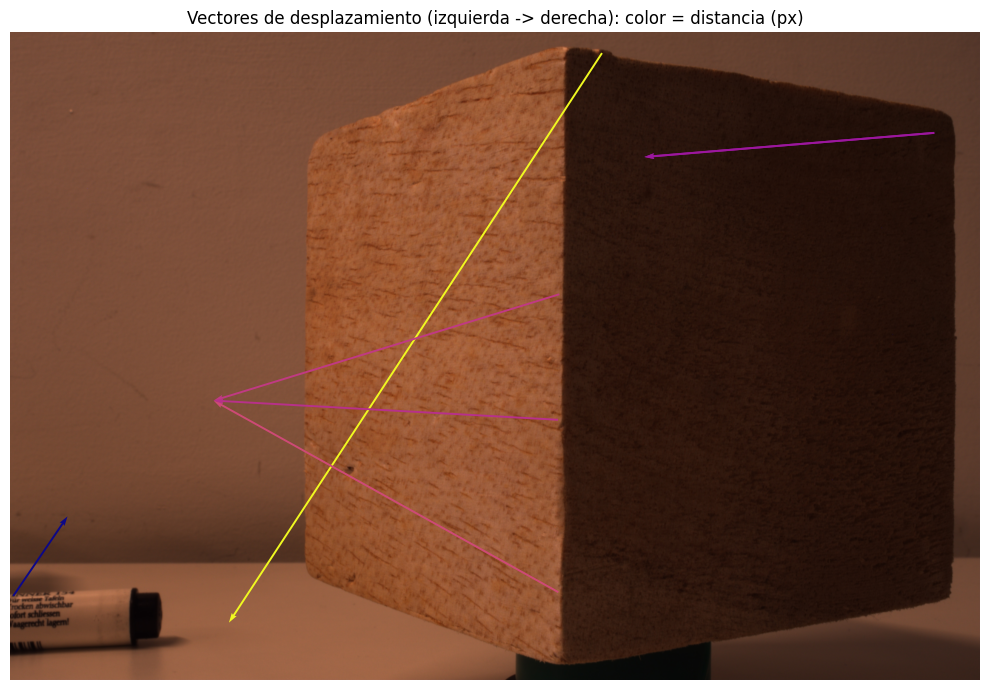

Correspondencias: 7
Distancia (px): media=579.7  mediana=568.9  max=1123.0
Angulo (grados): media=36.2  desviacion=146.9


In [ ]:
def vectores_desplazamiento(imgL, imgR, ratio=0.75, max_dibujar=150):
    grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
    grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    kpL, desL = sift.detectAndCompute(grayL, None)
    kpR, desR = sift.detectAndCompute(grayR, None)
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(desL, desR, k=2)
    good = [m for m, n in matches if m.distance < ratio * n.distance]

    ptsL = np.float32([kpL[m.queryIdx].pt for m in good])
    ptsR = np.float32([kpR[m.trainIdx].pt for m in good])
    dx = ptsR[:, 0] - ptsL[:, 0]
    dy = ptsR[:, 1] - ptsL[:, 1]
    distancias = np.sqrt(dx**2 + dy**2)
    angulos_deg = np.degrees(np.arctan2(dy, dx))

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(cv2.cvtColor(imgL, cv2.COLOR_BGR2RGB))
    idx = np.argsort(-distancias)[:max_dibujar]
    ax.quiver(ptsL[idx, 0], ptsL[idx, 1], dx[idx], dy[idx], distancias[idx],
              angles='xy', scale_units='xy', scale=1, cmap='plasma', width=0.002)
    ax.set_title("Vectores de desplazamiento (izquierda -> derecha): color = distancia (px)")
    ax.axis("off")
    plt.tight_layout(); plt.show()

    print(f"Correspondencias: {len(good)}")
    print(f"Distancia (px): media={distancias.mean():.1f}  mediana={np.median(distancias):.1f}  max={distancias.max():.1f}")
    print(f"Angulo (grados): media={angulos_deg.mean():.1f}  desviacion={angulos_deg.std():.1f}")
    return ptsL, ptsR, distancias, angulos_deg

nombre_demo = list(grupos_objeto.keys())[0]
imgL_demo = load_resized(grupos_objeto[nombre_demo]['left'][0])
imgR_demo = load_resized(grupos_objeto[nombre_demo]['right'][0])
print(f"Grupo usado para la demo: '{nombre_demo}'")
_ = vectores_desplazamiento(imgL_demo, imgR_demo)


## 12. Mapa de disparidad denso — StereoSGBM (correspondencia por bloques + regularizacion)

`numDisparities` se ajusta automaticamente usando la estimacion de la seccion 9 (redondeada al siguiente multiplo de 16, con margen). El calculo se hace a una resolucion reducida (`FACTOR_DISPARIDAD`) para que sea rapido en Colab, y luego se reescala de vuelta al tamano de trabajo (`RESIZE_WIDTH`) para la reconstruccion 3D.

Parametros clave (correspondientes a la teoria de la seccion 1.3/1.4):
- `blockSize`: tamano de la ventana (bloque) que se compara entre imagenes (el "SAD" de la teoria).
- `numDisparities`: rango de busqueda (cuanto se permite que una imagen se haya "movido" respecto a la otra).
- `P1`, `P2`: pesos del **termino de regularizacion** (penalizan saltos pequenos y grandes de disparidad entre pixeles vecinos).

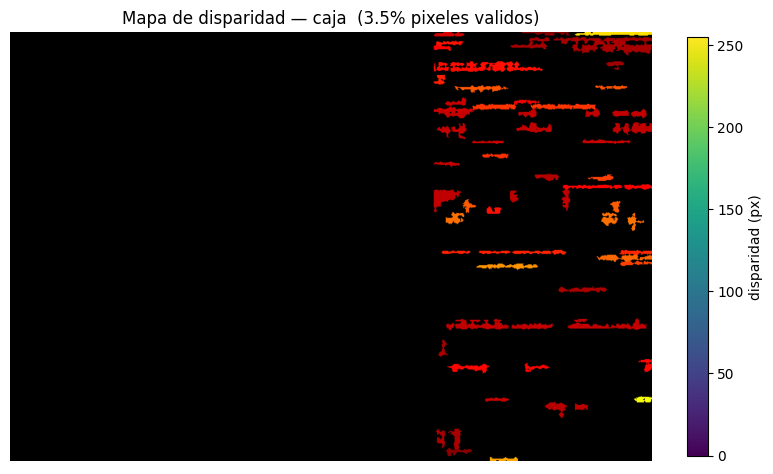

In [ ]:
FACTOR_DISPARIDAD = 0.5  # resolucion relativa para el calculo de SGBM (velocidad)

def calcular_disparidad_sgbm(rL, rR, num_disp_completo, factor=FACTOR_DISPARIDAD, block_size=5):
    small_L = cv2.resize(rL, (0, 0), fx=factor, fy=factor, interpolation=cv2.INTER_AREA)
    small_R = cv2.resize(rR, (0, 0), fx=factor, fy=factor, interpolation=cv2.INTER_AREA)
    grayL = cv2.cvtColor(small_L, cv2.COLOR_BGR2GRAY)
    grayR = cv2.cvtColor(small_R, cv2.COLOR_BGR2GRAY)

    num_disp = int(np.ceil((num_disp_completo * factor) / 16.0) * 16)
    num_disp = max(16, num_disp)

    sgbm = cv2.StereoSGBM_create(
        minDisparity=0, numDisparities=num_disp, blockSize=block_size,
        P1=8 * 3 * block_size**2,          # regularizacion: saltos pequenos de disparidad
        P2=32 * 3 * block_size**2,         # regularizacion: saltos grandes de disparidad
        disp12MaxDiff=1, uniquenessRatio=10,
        speckleWindowSize=100, speckleRange=2,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
    )
    disp_small = sgbm.compute(grayL, grayR).astype(np.float32) / 16.0

    disp_full = cv2.resize(disp_small, (rL.shape[1], rL.shape[0]), interpolation=cv2.INTER_NEAREST)
    disp_full = disp_full / factor  # reescalar el VALOR de disparidad a la escala de RESIZE_WIDTH
    return disp_full

def mostrar_disparidad(disp, titulo=""):
    valido = disp > 0
    vis = np.zeros_like(disp)
    vis[valido] = disp[valido]
    norm = cv2.normalize(vis, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    color = cv2.applyColorMap(norm, cv2.COLORMAP_JET)
    color[~valido] = (0, 0, 0)
    plt.figure(figsize=(9, 6))
    plt.imshow(cv2.cvtColor(color, cv2.COLOR_BGR2RGB))
    plt.title(f"Mapa de disparidad — {titulo}  ({valido.mean()*100:.1f}% pixeles validos)")
    plt.axis("off"); plt.colorbar(label="disparidad (px)", fraction=0.03)
    plt.show()
    return color

rL_demo, rR_demo = rectificar_par(imgL_demo, imgR_demo, mapsL, mapsR)
disp_demo = calcular_disparidad_sgbm(rL_demo, rR_demo, DISPARIDAD_MAXIMA_ESTIMADA)
_ = mostrar_disparidad(disp_demo, nombre_demo)


## 13. Demostracion manual: costo de bloque + termino de regularizacion (programacion dinamica 1D)

Implementacion simplificada, **desde cero**, de lo que hace SGBM internamente en una sola fila (scanline): para cada pixel se calcula el costo SAD contra cada disparidad candidata (termino de datos), y se resuelve con programacion dinámica una energia que ademas penaliza cambios bruscos de disparidad entre pixeles vecinos (termino de regularizacion), en vez de simplemente tomar el minimo por pixel (lo cual seria muy ruidoso).

```
E(d) = costo_dato(x,d) + lambda * |d(x) - d(x-1)|
```

Se corre sobre un recorte pequeno para que sea rapido (la version completa, para toda la imagen, es exactamente SGBM de la seccion 12).

Tiempo demo scanline: 0.15s


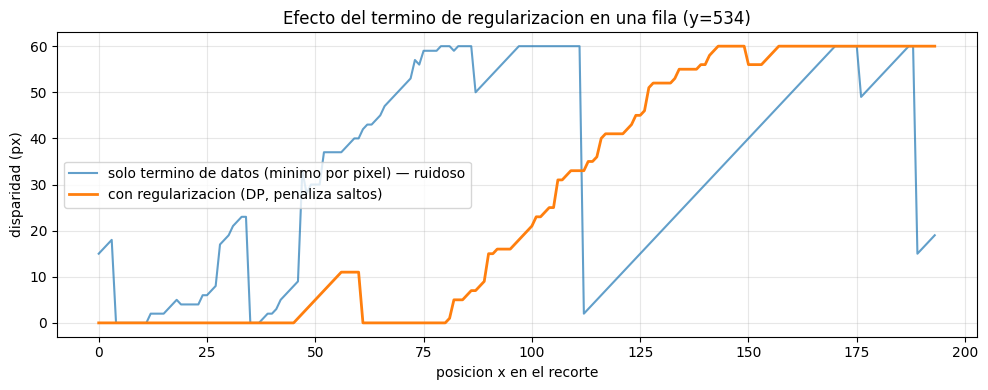

In [ ]:
def costo_bloque_SAD(ventana_izq, franja_der, x, d_max, w):
    costos = np.full(d_max + 1, 1e6, dtype=np.float32)
    for d in range(d_max + 1):
        xr = x - d
        if xr - w < 0 or xr + w + 1 > len(franja_der):
            continue
        parche_r = franja_der[xr - w:xr + w + 1]
        if len(parche_r) != len(ventana_izq):
            continue
        costos[d] = np.sum(np.abs(ventana_izq.astype(np.float32) - parche_r.astype(np.float32)))
    return costos

def disparidad_scanline_dp(filaL, filaR, d_max=60, w=3, lam=15.0):
    """Disparidad de una sola fila (scanline) con costo de bloque (SAD) + regularizacion (DP 1D)."""
    Wd = len(filaL)
    costo_dato = np.full((Wd, d_max + 1), 1e6, dtype=np.float32)
    for x in range(w, Wd - w):
        costo_dato[x] = costo_bloque_SAD(filaL[x - w:x + w + 1], filaR, x, d_max, w)

    dp = np.zeros((Wd, d_max + 1), dtype=np.float32)
    back = np.zeros((Wd, d_max + 1), dtype=np.int32)
    dp[0] = costo_dato[0]
    rango_d = np.arange(d_max + 1)
    for x in range(1, Wd):
        # para cada d, el mejor "d anterior" balancea el costo previo contra el salto (regularizacion)
        matriz_prev = dp[x - 1][None, :] + lam * np.abs(rango_d[:, None] - rango_d[None, :])
        mejor_prev = np.argmin(matriz_prev, axis=1)
        dp[x] = costo_dato[x] + matriz_prev[rango_d, mejor_prev]
        back[x] = mejor_prev

    d_final = int(np.argmin(dp[-1]))
    camino = [d_final]
    for x in range(Wd - 1, 0, -1):
        d_final = int(back[x, d_final])
        camino.append(d_final)
    camino.reverse()
    return np.array(camino)

# --- demo sobre un recorte pequeno de las imagenes rectificadas ---
d_max_demo = min(60, DISPARIDAD_MAXIMA_ESTIMADA)
recorte_y = rL_demo.shape[0] // 2       # una fila cerca del centro
x0, x1 = d_max_demo + 100, d_max_demo + 300  # rango de columnas del recorte (ajusta si quieres otra zona)
x1 = min(x1, rL_demo.shape[1])

grayL_demo = cv2.cvtColor(rL_demo, cv2.COLOR_BGR2GRAY)
grayR_demo = cv2.cvtColor(rR_demo, cv2.COLOR_BGR2GRAY)
filaL = grayL_demo[recorte_y, x0:x1]
filaR = grayR_demo[recorte_y, max(0, x0 - d_max_demo):x1]

t0 = time.time()
disp_fila_sin_reg = np.array([np.argmin(costo_bloque_SAD(filaL[max(0,x-3):x+4], filaR, x + d_max_demo, d_max_demo, 3))
                               for x in range(3, len(filaL) - 3)])
disp_fila_con_reg = disparidad_scanline_dp(filaL, filaR, d_max=d_max_demo, w=3, lam=15.0)
print(f"Tiempo demo scanline: {time.time()-t0:.2f}s")

plt.figure(figsize=(10, 4))
plt.plot(disp_fila_sin_reg, label="solo termino de datos (minimo por pixel) — ruidoso", alpha=0.7)
plt.plot(disp_fila_con_reg[3:-3], label="con regularizacion (DP, penaliza saltos)", linewidth=2)
plt.xlabel("posicion x en el recorte"); plt.ylabel("disparidad (px)")
plt.title(f"Efecto del termino de regularizacion en una fila (y={recorte_y})")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 14. Reconstruccion 3D densa a partir del mapa de disparidad

`cv2.reprojectImageTo3D(disparidad, Q)` usa `Z = f*baseline/d` (y las coordenadas X,Y correspondientes) para convertir **todo el mapa de disparidad** en una nube de puntos 3D, y se colorea cada punto con el color de la imagen rectificada izquierda.

**Nota:** cada nube de puntos se grafica en dos versiones: una **interactiva** (Plotly, se rota con el mouse) que solo se ve en Colab/Jupyter, y una **estatica** (matplotlib) que tambien se ve al abrir el notebook en GitHub (GitHub no ejecuta el JavaScript que necesita Plotly).

Puntos 3D validos: 58180


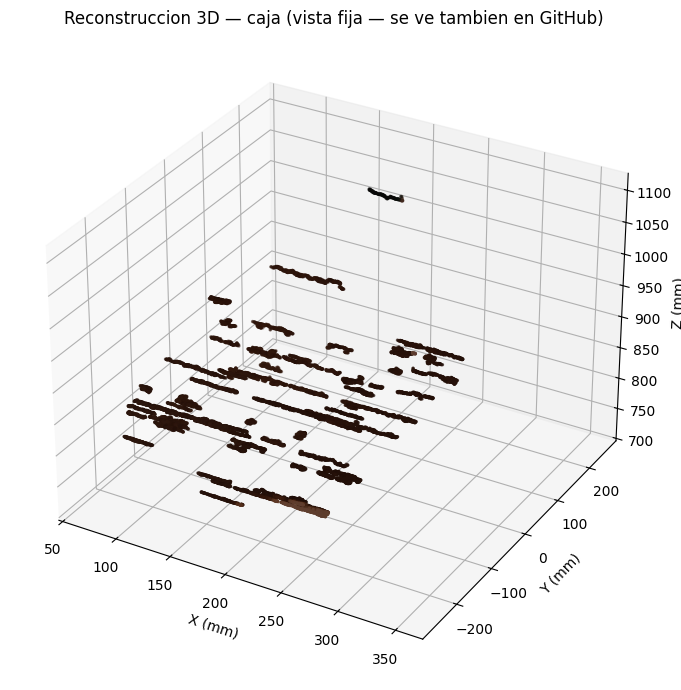

In [ ]:
def reconstruir_3d(disp, rL, Q, z_min=10, z_max_percentil=97):
    pts3D = cv2.reprojectImageTo3D(disp, Q)
    colores = cv2.cvtColor(rL, cv2.COLOR_BGR2RGB)

    mask = disp > disp[disp > 0].min() if (disp > 0).any() else np.zeros_like(disp, dtype=bool)
    z = pts3D[:, :, 2]
    mask &= (z > z_min)
    if mask.any():
        z_max = np.percentile(z[mask], z_max_percentil)
        mask &= (z < z_max)

    puntos = pts3D[mask]
    colores_validos = colores[mask] / 255.0
    return puntos, colores_validos

def graficar_nube_3d(puntos, colores, titulo="", max_puntos=20000):
    """Muestra la nube de puntos 3D en DOS versiones:
    1) Interactiva (Plotly): se puede rotar/hacer zoom con el mouse, pero SOLO se ve en Colab/Jupyter
       (GitHub no ejecuta JavaScript y la muestra en blanco).
    2) Estatica (matplotlib): vista fija desde un angulo, pero se ve igual en Colab, Jupyter Y GitHub
       (queda guardada como imagen dentro del notebook)."""
    if len(puntos) > max_puntos:
        idx = np.random.choice(len(puntos), max_puntos, replace=False)
        puntos_g, colores_g = puntos[idx], colores[idx]
    else:
        puntos_g, colores_g = puntos, colores

    # --- version interactiva (Plotly) ---
    colores_rgb = [f"rgb({int(c[0]*255)},{int(c[1]*255)},{int(c[2]*255)})" for c in colores_g]
    fig = go.Figure(data=[go.Scatter3d(
        x=puntos_g[:, 0], y=puntos_g[:, 1], z=puntos_g[:, 2],
        mode='markers',
        marker=dict(size=2, color=colores_rgb, opacity=0.9)
    )])
    fig.update_layout(
        title=f"Reconstruccion 3D — {titulo} ({len(puntos)} puntos, interactivo — solo Colab/Jupyter)",
        scene=dict(xaxis_title='X (mm)', yaxis_title='Y (mm)', zaxis_title='Z (mm)',
                   aspectmode='data'),
        width=850, height=750, margin=dict(l=0, r=0, b=0, t=40)
    )
    fig.show()

    # --- version estatica (matplotlib) : esta SI se ve en GitHub ---
    fig2 = plt.figure(figsize=(8, 7))
    ax = fig2.add_subplot(111, projection='3d')
    ax.scatter(puntos_g[:, 0], puntos_g[:, 1], puntos_g[:, 2], c=colores_g, s=2)
    ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)'); ax.set_zlabel('Z (mm)')
    ax.set_title(f"Reconstruccion 3D — {titulo} (vista fija — se ve tambien en GitHub)")
    plt.tight_layout()
    plt.show()

def guardar_ply(puntos, colores, path):
    colores_255 = (colores * 255).astype(np.uint8)
    with open(path, 'w') as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {len(puntos)}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write("property uchar red\nproperty uchar green\nproperty uchar blue\n")
        f.write("end_header\n")
        for p, c in zip(puntos, colores_255):
            f.write(f"{p[0]} {p[1]} {p[2]} {c[0]} {c[1]} {c[2]}\n")

puntos_demo, colores_demo = reconstruir_3d(disp_demo, rL_demo, Q)
print(f"Puntos 3D validos: {len(puntos_demo)}")
graficar_nube_3d(puntos_demo, colores_demo, nombre_demo)


## 15. Pipeline completo: disparidad + reconstruccion 3D para TODOS los grupos de objetos

Recorre automaticamente cada grupo detectado (caja, casas, bola de icopor, etc.), usando la primera pareja de fotos de cada uno, y guarda: la imagen rectificada, el mapa de disparidad (PNG en color) y la nube de puntos (`.ply` + `.csv`) en `/content/resultados`.


=== Procesando grupo: caja ===


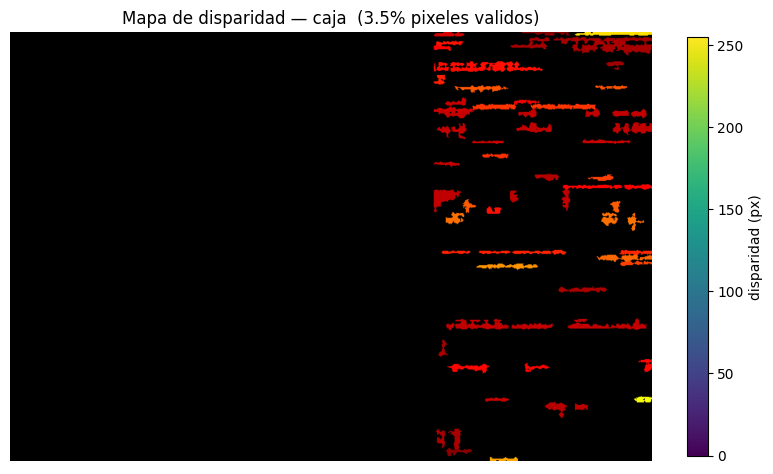

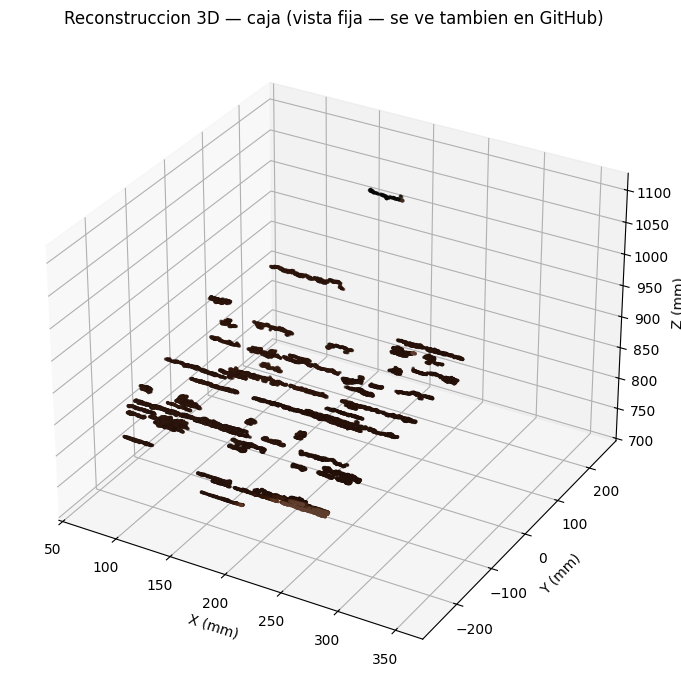


=== Procesando grupo: casa ===


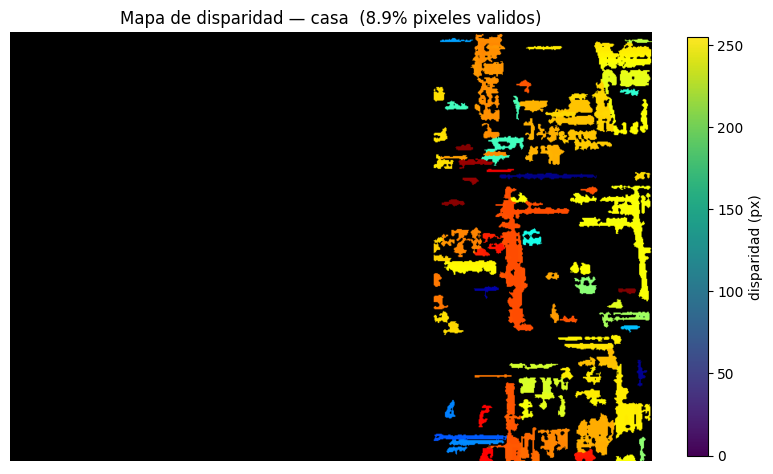

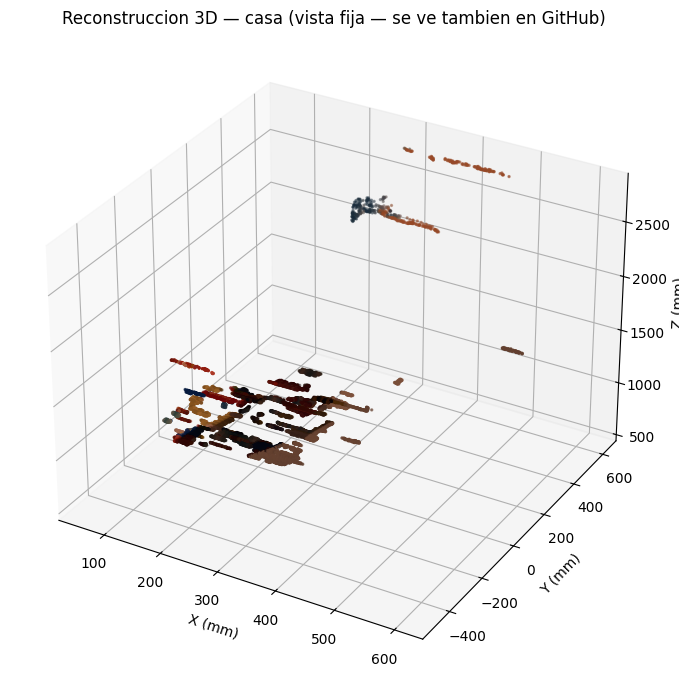


=== Procesando grupo: bola_icopor ===


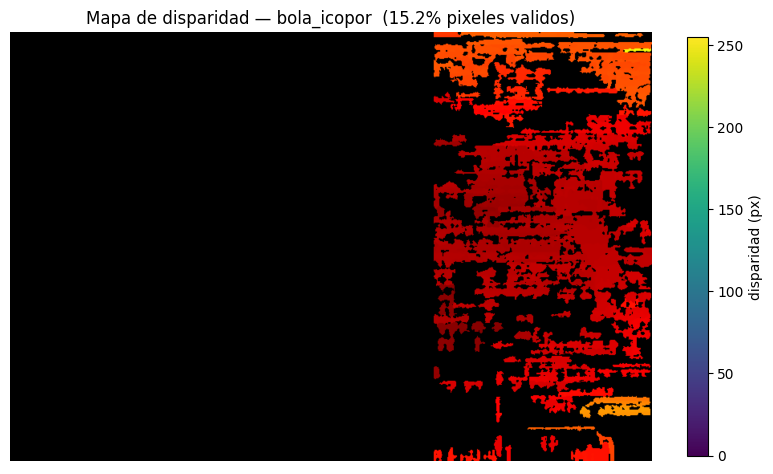

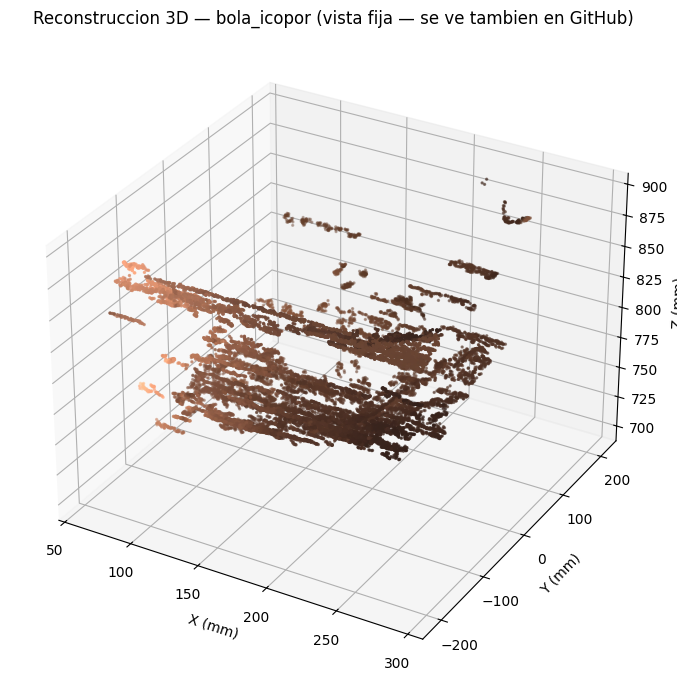

,objeto,disparidad_valida_%,disparidad_media_px,puntos_3D,profundidad_media_mm
0,caja,3.5,773.8,58180,814.1
1,casa,8.9,690.6,146796,936.4
2,bola_icopor,15.2,812.8,251682,776.1


In [ ]:
OUT_DIR = "/content/resultados"
os.makedirs(OUT_DIR, exist_ok=True)

resumen = []
for nombre, d in grupos_objeto.items():
    if len(d['left']) == 0 or len(d['right']) == 0:
        continue
    print(f"\n=== Procesando grupo: {nombre} ===")
    try:
        imgL = load_resized(d['left'][0])
        imgR = load_resized(d['right'][0])
        rL, rR = rectificar_par(imgL, imgR, mapsL, mapsR)

        disp = calcular_disparidad_sgbm(rL, rR, DISPARIDAD_MAXIMA_ESTIMADA)
        disp_color = mostrar_disparidad(disp, nombre)

        puntos, colores = reconstruir_3d(disp, rL, Q)
        if len(puntos) > 0:
            graficar_nube_3d(puntos, colores, nombre)

        cv2.imwrite(os.path.join(OUT_DIR, f"{nombre}_rectificada_L.jpg"), rL)
        cv2.imwrite(os.path.join(OUT_DIR, f"{nombre}_disparidad.png"), disp_color)
        np.save(os.path.join(OUT_DIR, f"{nombre}_disparidad.npy"), disp)
        if len(puntos) > 0:
            guardar_ply(puntos, colores, os.path.join(OUT_DIR, f"{nombre}_nube3D.ply"))
            np.savetxt(os.path.join(OUT_DIR, f"{nombre}_nube3D.csv"), puntos, delimiter=",", header="X,Y,Z", comments="")

        pct_validos = (disp > 0).mean() * 100
        resumen.append({
            "objeto": nombre,
            "disparidad_valida_%": round(pct_validos, 1),
            "disparidad_media_px": round(float(disp[disp > 0].mean()), 1) if (disp > 0).any() else 0.0,
            "puntos_3D": len(puntos),
            "profundidad_media_mm": round(float(puntos[:, 2].mean()), 1) if len(puntos) > 0 else 0.0,
        })
    except Exception as e:
        print(f"  (!) Error procesando '{nombre}': {e}")

tabla_resumen = pd.DataFrame(resumen)
tabla_resumen


## 16. Guardar y descargar todos los resultados

Guarda tambien la calibracion completa (`K1,D1,K2,D2,R,T,E,F,Q`) y comprime todo `/content/resultados` en un `.zip` para descargar de una vez.

In [ ]:
np.savez(os.path.join(OUT_DIR, "calibracion_estereo.npz"),
         K1=K1, D1=D1, K2=K2, D2=D2, R=R, T=T, E=E, F=F, Q=Q,
         img_shape=IMG_SHAPE, checkerboard=CHECKERBOARD, square_size_mm=SQUARE_SIZE_MM,
         resize_width=RESIZE_WIDTH, intercambiado=INTERCAMBIAR)

zip_resultados = "/content/resultados_reconstruccion.zip"
if os.path.exists(zip_resultados):
    os.remove(zip_resultados)
shutil.make_archive(zip_resultados.replace(".zip", ""), 'zip', OUT_DIR)

print("Contenido guardado en:", OUT_DIR)
for f in sorted(os.listdir(OUT_DIR)):
    print("  -", f)

from google.colab import files as gfiles
gfiles.download(zip_resultados)


Contenido guardado en: /content/resultados
  - bola_icopor_disparidad.npy
  - bola_icopor_disparidad.png
  - bola_icopor_nube3D.csv
  - bola_icopor_nube3D.ply
  - bola_icopor_rectificada_L.jpg
  - caja_disparidad.npy
  - caja_disparidad.png
  - caja_nube3D.csv
  - caja_nube3D.ply
  - caja_rectificada_L.jpg
  - calibracion_estereo.npz
  - casa_disparidad.npy
  - casa_disparidad.png
  - casa_nube3D.csv
  - casa_nube3D.ply
  - casa_rectificada_L.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 17. Notas finales y ajuste de parametros

- **Si `NOMBRE_GRUPO_CALIB` o `CHECKERBOARD` se detectan mal**: fijalos a mano justo despues de la seccion 5 con los valores correctos (cuenta las esquinas internas del tablero en una foto).
- **Si el RMS de calibracion estereo (seccion 8) es alto (>2 px)**: es normal si las fotos "izquierda" y "derecha" se tomaron moviendo una sola camara a mano en vez de usar un rig fijo con las dos camaras simultaneas; la reconstruccion sigue funcionando pero de forma aproximada.
- **Si el mapa de disparidad sale muy ruidoso o con pocos pixeles validos**: prueba subir `DISPARIDAD_MAXIMA_ESTIMADA` manualmente (por si la estimacion automatica se quedo corta), bajar `FACTOR_DISPARIDAD` (mas resolucion, mas lento) o cambiar `block_size` en `calcular_disparidad_sgbm` (bloques mas grandes = mas robusto a ruido pero menos detalle).
- **Objetos con poca textura (esfera de icopor, caras lisas de la caja de madera)** naturalmente dan mapas de disparidad mas pobres que objetos con mucha textura (las casitas de lata): es una limitacion fisica del metodo de correspondencia por bloques, no un error del codigo — se explica en la seccion 1.3.
- La seccion 13 (programacion dinamica 1D) es deliberadamente lenta e ilustrativa (para explicar la teoria paso a paso); la seccion 12 (`StereoSGBM`) es la version eficiente que se usa en la practica.
